### KMeans Clustering

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned data
df = pd.read_csv(r'D:\Guvi\Projects\mini\Human Voice Classification and Clustering\Human_Voice_Classification_and_Clustering\data\vocal_gender_features_cleaned.csv')


In [3]:
# Drop target for unsupervised learning
X = df.drop('label', axis=1)

In [4]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

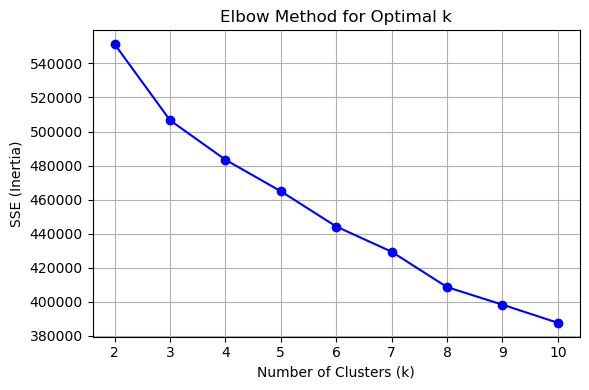

In [5]:
# Elbow Method to find best k
sse = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K, sse, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# Try KMeans with k=2 (to compare with male/female)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [7]:
# Silhouette Score
score = silhouette_score(X_scaled, clusters)
print(f'Silhouette Score for k=2: {score:.3f}')

Silhouette Score for k=2: 0.175


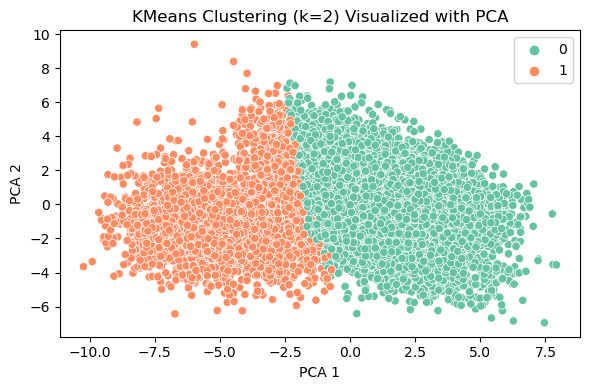

In [8]:
# Visualize with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.title("KMeans Clustering (k=2) Visualized with PCA")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.tight_layout()
plt.show()

# DBSCAN Clustering

In [9]:
from sklearn.cluster import DBSCAN

In [10]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Try DBSCAN with default parameters
dbscan = DBSCAN(eps=2, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

In [12]:
# Add to DataFrame for visualization
df['dbscan_cluster'] = db_clusters

In [13]:
# Count number of clusters found (-1 is noise)
import numpy as np
n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
n_noise = list(db_clusters).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

Estimated number of clusters: 1
Estimated number of noise points: 15065


In [14]:
# Silhouette Score (ignore if all one cluster or all noise)
if len(set(db_clusters)) > 1 and -1 in db_clusters and len(set(db_clusters)) > 2:
    score = silhouette_score(X_scaled, db_clusters)
    print(f'Silhouette Score for DBSCAN: {score:.3f}')
else:
    print("Silhouette Score not applicable (only one cluster or all noise).")

Silhouette Score not applicable (only one cluster or all noise).


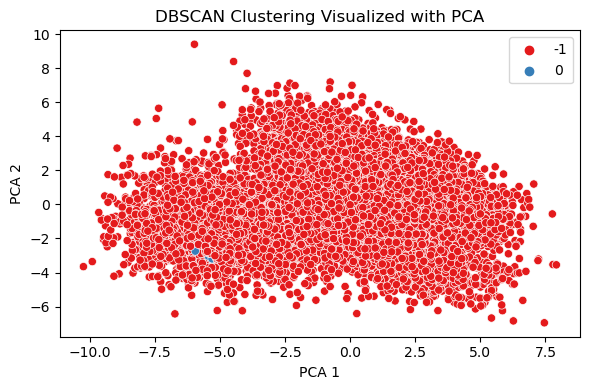

In [15]:
# PCA plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=db_clusters, palette='Set1')
plt.title("DBSCAN Clustering Visualized with PCA")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.tight_layout()
plt.show()